In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import numpy as np 

import sys 
sys.path.append('/home/teddy/local/gsnn-mds/workflow/scripts/') 
from make_graph import * 

import os 

%load_ext autoreload
%autoreload 2 



/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load mutation data
mut, mut_features = load_mut('../../data/')

# Find overlapping sample IDs between expression and mutation data
mut_sample_ids = set(mut['sample_id'])


/home/teddy/local/gsnn-mds/gsnn_mds/data/proc.py:237: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mds_mut = mds_mut.replace('NEGATIVE', 0)
/home/teddy/local/gsnn-mds/gsnn_mds/data/proc.py:238: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mds_mut = mds_mut.replace('POSITIVE', 1)
/home/teddy/local/gsnn-mds/gsnn_mds/data/proc.py:239: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the

In [3]:
mut.head() 

,sample_id,source,SMC1A,ASXL2,PTPN11,WT1,SF3B1,FLT3,IDH1,CALR,...,EZH2,BCORL1,TP53,CBL,NF1,PHF6,BCOR,ASXL1,ETV6,SMC3
0,e142da42-cf4a-4d31-b003-27d0371d8717,AML,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4fff9e23-f40d-473f-b9d9-f1b07458845b,AML,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,d4d28755-3ce0-43fb-9d7e-fbc3e6c5595b,AML,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1039aa8b-3d3c-423c-9e41-a6ec31ebff09,AML,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,06f3aa73-b20f-4201-b045-4f9d7166bc68,AML,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
drug_data_path = os.path.join('../../data/', 'beataml_probit_curve_fits_v4_distr.txt')
clinical_data_path = os.path.join('../../data/', 'beataml_clinical_for_inputs.csv')
drug = load_and_process_drug_data(drug_data_path, clinical_data_path, 'zscore')

# Get drug candidates for filtering
drug_candidates = (drug.inhibitor_1.str.lower().unique().tolist() + 
                    drug.inhibitor_2.str.lower().unique().tolist())
drug_candidates = [x for x in drug_candidates if pd.notna(x)]

targetome_data_path = os.path.join('../../data/', 'targetome_extended-01-23-25.csv')
drug_meta_path = os.path.join('../../data/', 'beataml_drugs_for_targetome.csv')

dtis = load_drug_target_interactions(
    targetome_data_path, drug_meta_path, drug_candidates, 1000
)

Loading drug response data...
Loaded 68525 drug response measurements
Loading drug-target interactions...
Loaded 8895 drug-target interactions for 128 drugs


In [6]:

# Create DTI graph edges
dti_df = create_dti_graph(dtis)
drugspace = dti_df.source.unique()

bio_df = create_biological_graph(drugspace, None, 4, False, True)

rnaspace = [r for r in np.unique(bio_df.source.tolist() + bio_df.target.tolist()) 
               if r.startswith('RNA__')]
uniprot_rnaspace = [x.split('__')[1] for x in rnaspace]

uni2symb_df = map_uniprot_to_gene_symbols(uniprot_rnaspace)

expression_data_path = os.path.join('../../data/', 'aml_full_manuscript.csv')
aml_expr, normalizer = process_expression_data(
    expression_data_path, uni2symb_df, 'zscore',
    quantile_clip=(0.1, 0.9),
    normalizer_save_path=None,
    n_top_genes=1000,
    var_threshold=0.1
)

Building biological interaction network...
# of translation (RNA->PROTEIN) edges: 3873
Translation edges: 3873
Mapping 5170 UniProt IDs to gene symbols...
Successfully mapped 5201 UniProt-symbol pairs (0 failed)
Loading gene expression data...
Selecting variable genes...
Selected top 1000 most variable genes
Applied zscore normalization
Processed expression data: 560 samples x 1000 genes


In [7]:
mds_expr_path = os.path.join('../../data/', '20241219_WTS_Data_Proj805.csv')
mds_expr = process_mds_expression_data(
    mds_expr_path, normalizer, uni2symb_df
)

Loading MDS expression data...
Applied zscore normalization to MDS data
Processed MDS expression data: 683 samples x 1000 genes


In [17]:
expr = pd.concat([aml_expr, mds_expr])
expr.head() 

,EXPR__P06702,EXPR__P05164,EXPR__P10124,EXPR__P68871,EXPR__P59666,EXPR__P08246,EXPR__P10153,EXPR__P10145,EXPR__P01903,EXPR__P24158,...,EXPR__Q9Y376,EXPR__Q14790,EXPR__Q13029,EXPR__Q92626,EXPR__Q01826,EXPR__P25705,EXPR__Q9UBG0,EXPR__Q15758,EXPR__P28068,EXPR__P11274
id,,,,,,,,,,,,,,,,,,,,,
001454b2-aff9-4659-85a6-73fb8092589a,-0.697769,-0.406809,-0.846560,-0.254601,-0.322171,-0.521241,-0.710374,-0.394230,1.226247,-0.499264,...,0.316817,0.225583,-0.204193,-0.226574,0.370586,-0.065545,-0.663832,0.000393,2.739998,-0.363895
002cacd9-c03b-4526-a380-0701f41c4a9e,-0.762251,-0.495544,-0.925343,-0.096316,-0.322962,-0.522234,-0.747236,-0.396359,1.166692,-0.499700,...,-1.227748,0.319455,-0.159439,-0.435897,0.917538,1.155340,-0.641845,-0.995121,0.835594,0.879142
006e5777-2603-4db7-a1d6-8c8085c5e3e5,-0.548679,-0.197029,-0.410682,-0.226244,-0.275531,-0.383933,0.122080,-0.398564,-0.299118,-0.469839,...,0.785684,0.640928,-0.212689,-0.437794,1.549538,-0.386627,-0.237158,-0.793670,-0.164597,-0.408766
00870f33-cab3-4c23-bd0d-8903a5a9789e,0.304313,-0.542919,0.082559,-0.183515,0.786485,-0.290768,-0.563174,2.468421,1.810213,-0.449801,...,-1.292476,0.023436,0.504138,-0.436225,-0.389856,-1.189528,0.234782,-1.185169,-0.360191,0.734656
00b535f6-064a-4dcf-ab14-387a54eedeee,0.127378,-0.478077,1.249115,-0.196052,0.096172,-0.338835,1.484059,-0.252993,0.598873,-0.137988,...,-0.686000,-1.030816,-1.122992,-0.438956,-0.948852,0.816082,-0.343011,0.880012,0.471802,-0.963132


In [22]:
uni2symb_df.set_index('gene_symbol').to_dict()['uniprot']

{'SLC12A8': 'A0AV02',
 'RBM47': 'A0AV96',
 'E2F8': 'A0AVK6',
 'ESYT2': 'A0FGR8',
 'GXYLT2': 'A0PJZ3',
 'TMEM120B': 'A0PK00',
 'ARHGAP10': 'A1A4S6',
 'SLC22A23': 'A1A5C7',
 'PLEKHG3': 'A1L390',
 'SH3PXD2B': 'A1X283',
 'ZBTB7C': 'A1YPR0',
 'MACROD2': 'A1Z1Q3',
 'FRMD3': 'A2A2Y4',
 'NBAS': 'A2RRP1',
 'DENND3': 'A2RUS2',
 'TMEM131L': 'A2VDJ0',
 'SSPOP': 'A2VEC9',
 'CPED1': 'A4D0V7',
 'GSAP': 'A4D1B5',
 'ZNF804B': 'A4D1E1',
 'BLACE': 'A4D250',
 'EFCAB5': 'A4FU69',
 'PSD': 'A5PKW4',
 'CNOT1': 'A5YKK6',
 'MEGF11': 'A6BM72',
 'RCCD1': 'A6NED2',
 'RBFOX3': 'A6NFN3',
 'NEMP2': 'A6NFY4',
 'CAPN8': 'A6NHC0',
 'ZNF860': 'A6NHJ4',
 'SMCHD1': 'A6NHR9',
 'MSGN1': 'A6NI15',
 'ARHGAP42': 'A6NI28',
 'PCNX2': 'A6NKB5',
 'CCDC85C': 'A6NKD9',
 'CFAP144': 'A6NL82',
 'SRRM3': 'A6NNA2',
 'ARHGAP32': 'A7KAX9',
 'SFI1': 'A8K8P3',
 'ERI2': 'A8K979',
 'ELAPOR2': 'A8MWY0',
 'FOXO6': 'A8MYZ6',
 'AHRR': 'A9YTQ3',
 'FHAD1': 'B1AJZ9',
 'ZNF879': 'B4DU55',
 'RABGAP1L': 'Q5R372',
 'ZNF689': 'Q96CS4',
 'PRKCH': 'P24723',


In [29]:
mut2 = mut.drop(columns=['source']).set_index('sample_id')
uni2symb_dict = uni2symb_df.set_index('gene_symbol').to_dict()['uniprot']
keep_cols = [x for x in mut2.columns if x in uni2symb_dict.keys()]
mut2 = mut2[keep_cols]
mut2.columns = ['MUT__' + uni2symb_dict[x] for x in mut2.columns]


inputs_df = expr.merge(mut2, left_index=True, right_index=True)
inputs_df.head() 

,EXPR__P06702,EXPR__P05164,EXPR__P10124,EXPR__P68871,EXPR__P59666,EXPR__P08246,EXPR__P10153,EXPR__P10145,EXPR__P01903,EXPR__P24158,...,MUT__Q9Y6K1,MUT__P06748,MUT__Q15022,MUT__O60674,MUT__Q15910,MUT__P04637,MUT__P21359,MUT__Q6W2J9,MUT__Q8IXJ9,MUT__P41212
id,,,,,,,,,,,,,,,,,,,,,
MLL_00003,2.426094,-0.311866,1.131274,-0.260287,3.552214,-0.133917,-0.333081,1.033333,-0.824142,0.002170,...,1,0,0,0,0,0,0,0,0,0
MLL_00009,4.113601,-0.108407,2.896006,-0.260287,3.261526,-0.181973,1.093391,0.906184,-0.713727,0.074834,...,0,0,1,0,0,0,0,0,0,0
MLL_09939,4.356145,0.014799,1.558596,-0.260287,4.314602,0.533052,-0.119597,0.729906,-0.641950,0.351137,...,0,0,0,0,0,0,0,0,0,0
MLL_09941,2.032355,-0.230680,1.887429,-0.260287,19.011468,-0.093780,-0.079862,-0.287586,-0.880389,0.290748,...,0,0,0,0,0,0,0,0,0,0
MLL_09942,3.682756,-0.240428,1.045534,-0.260287,10.678003,-0.323625,-0.164127,1.475057,-0.601719,-0.199060,...,0,0,0,0,0,0,0,0,0,0


In [15]:
mds_expr.head() 

,EXPR__P06702,EXPR__P05164,EXPR__P10124,EXPR__P68871,EXPR__P59666,EXPR__P08246,EXPR__P10153,EXPR__P10145,EXPR__P01903,EXPR__P24158,...,EXPR__Q9Y376,EXPR__Q14790,EXPR__Q13029,EXPR__Q92626,EXPR__Q01826,EXPR__P25705,EXPR__Q9UBG0,EXPR__Q15758,EXPR__P28068,EXPR__P11274
id,,,,,,,,,,,,,,,,,,,,,
MLL_00003,2.426094,-0.311866,1.131274,-0.260287,3.552214,-0.133917,-0.333081,1.033333,-0.824142,0.002170,...,-0.399206,7.057299,0.137065,-0.427074,0.196992,0.0,-0.076486,4.512114,0.163760,-0.659772
MLL_00009,4.113601,-0.108407,2.896006,-0.260287,3.261526,-0.181973,1.093391,0.906184,-0.713727,0.074834,...,1.868932,3.346608,-0.692056,-0.352076,-0.302066,0.0,-0.275343,6.177231,0.779415,-0.650320
MLL_09939,4.356145,0.014799,1.558596,-0.260287,4.314602,0.533052,-0.119597,0.729906,-0.641950,0.351137,...,-0.176745,1.260234,-0.369868,-0.370897,-0.174767,0.0,-0.134908,7.237226,0.866755,-0.794287
MLL_09941,2.032355,-0.230680,1.887429,-0.260287,19.011468,-0.093780,-0.079862,-0.287586,-0.880389,0.290748,...,-0.561213,0.578294,-0.320678,-0.324641,-0.412412,0.0,0.062726,7.488856,-0.108302,0.635221
MLL_09942,3.682756,-0.240428,1.045534,-0.260287,10.678003,-0.323625,-0.164127,1.475057,-0.601719,-0.199060,...,-0.760016,4.120178,-0.176123,-0.395434,-0.310840,0.0,-0.105512,12.376936,0.194751,-1.167215


In [ ]:
mds_expr_ids = set(mds_expr.index.tolist())

,EXPR__P06702,EXPR__P05164,EXPR__P10124,EXPR__P68871,EXPR__P59666,EXPR__P08246,EXPR__P10153,EXPR__P10145,EXPR__P01903,EXPR__P24158,...,EXPR__Q9Y376,EXPR__Q14790,EXPR__Q13029,EXPR__Q92626,EXPR__Q01826,EXPR__P25705,EXPR__Q9UBG0,EXPR__Q15758,EXPR__P28068,EXPR__P11274
id,,,,,,,,,,,,,,,,,,,,,
MLL_00003,2.426094,-0.311866,1.131274,-0.260287,3.552214,-0.133917,-0.333081,1.033333,-0.824142,0.002170,...,-0.399206,7.057299,0.137065,-0.427074,0.196992,0.0,-0.076486,4.512114,0.163760,-0.659772
MLL_00009,4.113601,-0.108407,2.896006,-0.260287,3.261526,-0.181973,1.093391,0.906184,-0.713727,0.074834,...,1.868932,3.346608,-0.692056,-0.352076,-0.302066,0.0,-0.275343,6.177231,0.779415,-0.650320
MLL_09939,4.356145,0.014799,1.558596,-0.260287,4.314602,0.533052,-0.119597,0.729906,-0.641950,0.351137,...,-0.176745,1.260234,-0.369868,-0.370897,-0.174767,0.0,-0.134908,7.237226,0.866755,-0.794287
MLL_09941,2.032355,-0.230680,1.887429,-0.260287,19.011468,-0.093780,-0.079862,-0.287586,-0.880389,0.290748,...,-0.561213,0.578294,-0.320678,-0.324641,-0.412412,0.0,0.062726,7.488856,-0.108302,0.635221
MLL_09942,3.682756,-0.240428,1.045534,-0.260287,10.678003,-0.323625,-0.164127,1.475057,-0.601719,-0.199060,...,-0.760016,4.120178,-0.176123,-0.395434,-0.310840,0.0,-0.105512,12.376936,0.194751,-1.167215


In [14]:
mds_expr_ids = set(mds_expr.index.tolist())
mds_mut_ids = set(mut[lambda x: x.source == 'MDS'].sample_id.unique())

len(mds_expr_ids.intersection(mds_mut_ids))

668

In [8]:
clin = pd.read_csv(clinical_data_path)[['gdc_id', 'dbgap_dnaseq_sample']].dropna() 
clin.head() 

,gdc_id,dbgap_dnaseq_sample
5,7381de45-7a35-47af-b909-f997cd9b02c0,BA2236D
12,e48798e2-a60e-452c-9b47-dedb61e2b523,BA2488D
13,854e5b8c-46f7-464b-94b9-6f0263cec32e,BA3379D
15,bca3099a-07f0-4e2e-80d8-70f12123fb0f,BA2858D
16,7b397b6b-f81b-493e-b05b-c58eef1885c1,BA2068D


In [9]:
aml_expr.index.unique() 

Index(['001454b2-aff9-4659-85a6-73fb8092589a',
       '002cacd9-c03b-4526-a380-0701f41c4a9e',
       '006e5777-2603-4db7-a1d6-8c8085c5e3e5',
       '00870f33-cab3-4c23-bd0d-8903a5a9789e',
       '00b535f6-064a-4dcf-ab14-387a54eedeee',
       '00dea64b-7706-4a23-b4ad-8d8cb0b8c9b9',
       '015eb9bb-9dc6-46a7-b52d-01d052a13edc',
       '01d880c3-68ca-4c71-98e2-1fcb3d785ca3',
       '021ad917-10f5-43a5-8a52-bcfdbbddbb25',
       '02be63ab-f565-417f-a213-2a52455feba1',
       ...
       'fdf332eb-a089-4747-b462-b0b14cc86045',
       'fe2b26db-6cc9-4d39-ab7a-5ae5549939f1',
       'fe45f570-2572-4c3f-ae57-2f101582a538',
       'fe5f75ee-1edd-429e-a388-f7c14fc3211a',
       'fe703303-9c7d-4438-920f-31cce91d01aa',
       'fe753e8e-c240-4406-b7b1-11eda81a03f1',
       'fe9d7a2b-310c-460a-945d-13c22f28472b',
       'fed3ecc8-832c-4e3d-99d9-954c5df48522',
       'fee8fcbe-723a-4edb-bbfe-7d4b37aba641',
       'ff244ddf-f003-452c-bb2e-3516efb14b1a'],
      dtype='object', name='id', length=560)

In [13]:
drug.columns

Index(['lab_id', 'patient_id', 'inhibitor', 'min_conc', 'max_conc',
       'intercept', 'beta', 'beta_z', 'beta_p', 'aic', 'pearson_chisq',
       'deviance', 'converged', 'ic10', 'ic25', 'ic50', 'ic75', 'ic90', 'auc',
       'all_gt_50', 'all_lt_50', 'curve_type', 'type', 'proprietary'],
      dtype='object')

In [8]:
import numpy as np 

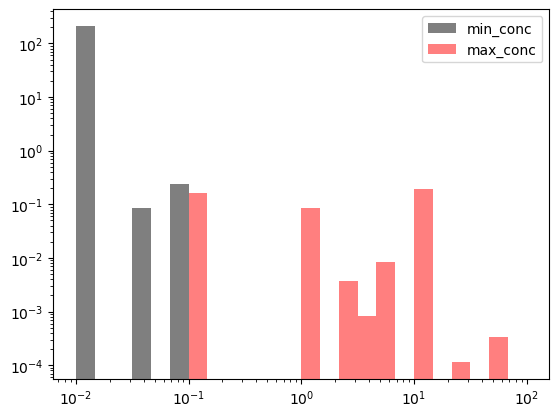

In [10]:
_bins = np.logspace(-2, 2, 25)

plt.figure() 
plt.hist( drug.min_conc.values , color='k', bins=_bins, alpha=0.5, label='min_conc', density=True)
plt.hist( drug.max_conc.values , color='r', bins=_bins, alpha=0.5, label='max_conc', density=True) 
plt.legend() 
plt.yscale('log')
plt.xscale('log')
plt.show() 

In [ ]:
vg = pd.read_csv('../../data/van_galen_malig_celltypes_top30.txt', sep='\t')
vg = vg.rename({'vg_type':'dst', 'display_label':'src'}, axis=1)[['src', 'dst']]
vg.head() 

,vg_rank,vg_type,display_label
0,1,HSC-like,NPTX2
1,2,HSC-like,H1F0
2,3,HSC-like,EMP1
3,4,HSC-like,MEIS1
4,5,HSC-like,CALCRL


In [4]:
vg.groupby('vg_type').size()

vg_type
GMP-like           24
HSC-like           28
Monocyte-like      29
Progenitor-like    25
Promono-like       30
cDC-like           29
dtype: int64

In [5]:
vg = vg.rename({'vg_type':'dst', 'display_label':'src'}, axis=1)[['src', 'dst']]
vg.head()

,src,dst
0,NPTX2,HSC-like
1,H1F0,HSC-like
2,EMP1,HSC-like
3,MEIS1,HSC-like
4,CALCRL,HSC-like
